#**GENERATIVE ADVERSARIAL NETWORKS GANS**

[Research Paper](https://arxiv.org/pdf/1406.2661)

#**1. Import required Liaberies**

In [1]:
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import time

In [2]:
os.makedirs("./images/gans",exist_ok =True)

#**Hyperparameters**

In [3]:
np.random.seed(1234)
torch.manual_seed(1234)
random.seed(1234)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
BATCH_SIZE = 64
N_EPOCHS = 100
IMAGE_SIZE = 28*28
LATENT_DIM = 100
PRINT_EVERY = 5
N_SHOW = 5

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

#**Load Dataset**

In [6]:
transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)) # norm_img=pixel_value - mean / stan_dev
])

In [7]:
data = datasets.MNIST(".data", train=True,download=True,transform=transforms)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.77MB/s]


In [8]:
data

Dataset MNIST
    Number of datapoints: 60000
    Root location: .data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [9]:
iterator = DataLoader(dataset=data,
                      batch_size=BATCH_SIZE,
                      shuffle=True,
                      drop_last=True)

In [10]:
len(iterator)

937

#**Generative model**

In [11]:
class Generator(nn.Module):
  def __init__(self,latent_dim,image_size):
    super().__init__()
    self.main = nn.Sequential(
        nn.Linear(latent_dim,256),
        nn.LeakyReLU(0.2),

        nn.Linear(256,512),
        nn.LeakyReLU(0.2),

        nn.Linear(512,1024),
        nn.LeakyReLU(0.2),

        nn.Linear(1024,image_size),
        nn.Tanh()
    )

  def forward(self, x):
    return self.main(x)

#**Discriminative Model**

In [12]:
class Discriminator(nn.Module):
  def __init__(self,image_size):
    super().__init__()
    self.main = nn.Sequential(
        nn.Linear(image_size,1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),

        nn.Linear(1024,512),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),

        nn.Linear(512,256),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),

        nn.Linear(256,1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.main(x).squeeze(1)

In [13]:
generator = Generator(LATENT_DIM, IMAGE_SIZE).to(device)
generator

Generator(
  (main): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

In [14]:
discriminator = Discriminator(IMAGE_SIZE).to(device)
discriminator

Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

#**Loss Function and Optimizer**

**Loss Function**

In [15]:
criterian = nn.BCELoss()

**Optimizer**

In [16]:
G_lr = 0.0002
G_optimizer = optim.Adam(generator.parameters(), lr=G_lr, betas=(0.5,0.999))

In [17]:
D_lr = 0.0002
D_optimizer = optim.Adam(discriminator.parameters(), lr=D_lr, betas=(0.5,0.999))

#**Labels**

In [18]:
real_labels = torch.ones(BATCH_SIZE).to(device)

In [19]:
fake_labels = torch.zeros(BATCH_SIZE).to(device)

#**Time function**

In [20]:
def epoch_time(start_time, end_time):
  elapsed_time = end_time - start_time
  elapsed_mins = int(elapsed_time / 60)
  elapsed_sec = int(elapsed_time - (elapsed_mins * 60))
  return elapsed_mins, elapsed_sec

#**Traning loop**

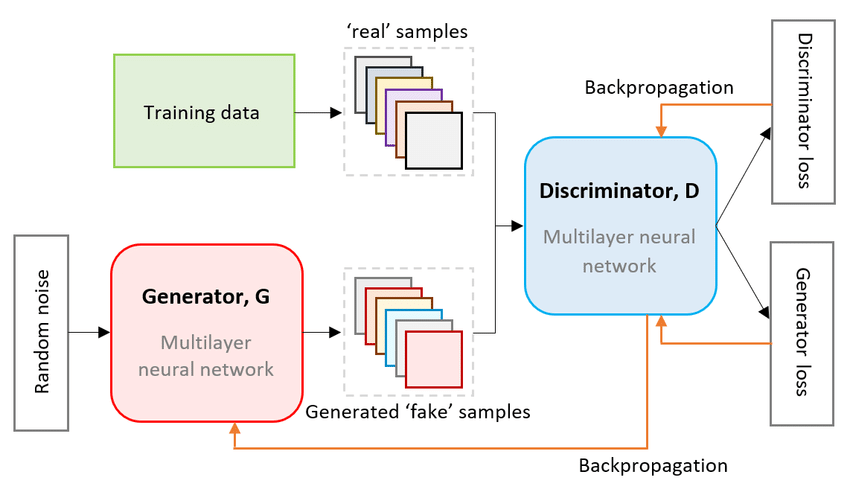

| Epoch: 005 | D_error: 0.797 | G_error: 1.465 | Time: 0m 34s


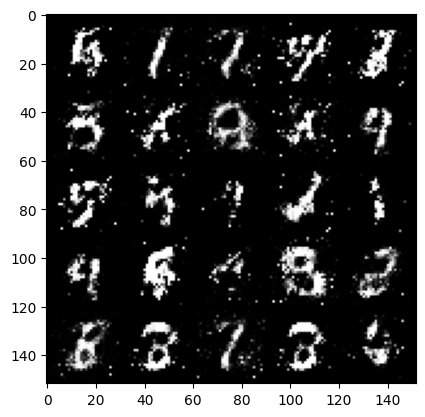

| Epoch: 010 | D_error: 1.069 | G_error: 1.283 | Time: 0m 33s


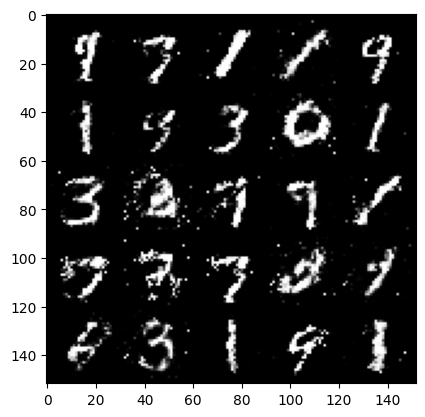

| Epoch: 015 | D_error: 1.206 | G_error: 1.130 | Time: 0m 34s


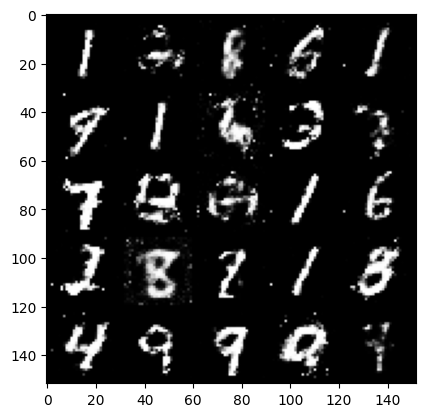

| Epoch: 020 | D_error: 1.039 | G_error: 1.315 | Time: 0m 34s


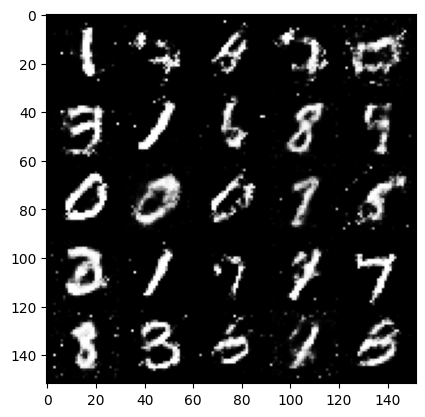

| Epoch: 025 | D_error: 1.306 | G_error: 1.057 | Time: 0m 34s


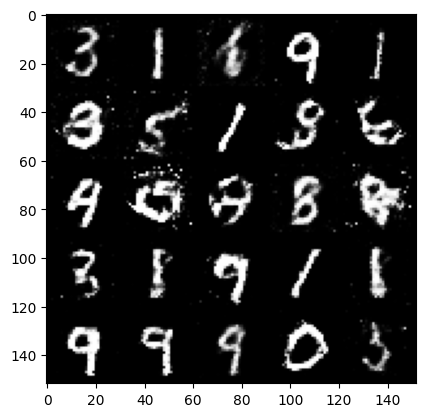

| Epoch: 030 | D_error: 1.056 | G_error: 1.291 | Time: 0m 37s


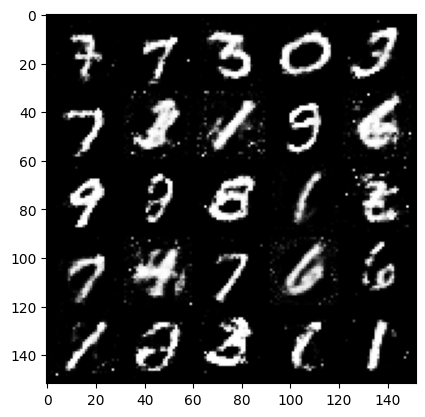

| Epoch: 035 | D_error: 1.174 | G_error: 0.989 | Time: 0m 33s


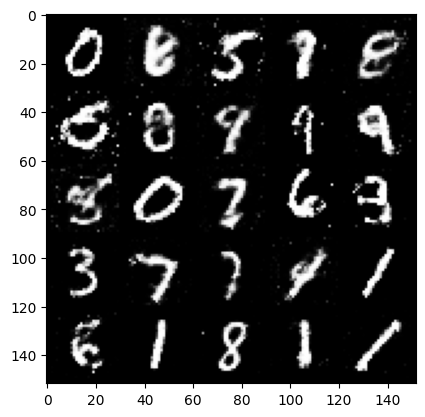

| Epoch: 040 | D_error: 1.206 | G_error: 0.912 | Time: 0m 33s


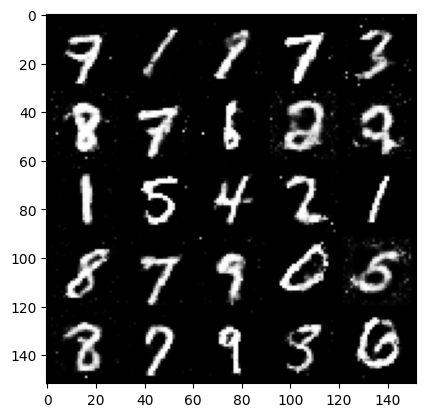

| Epoch: 045 | D_error: 1.058 | G_error: 1.392 | Time: 0m 34s


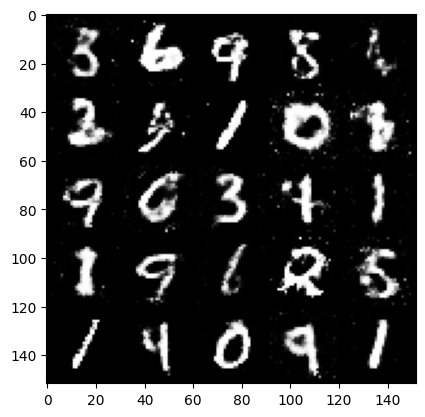

| Epoch: 050 | D_error: 1.088 | G_error: 1.283 | Time: 0m 33s


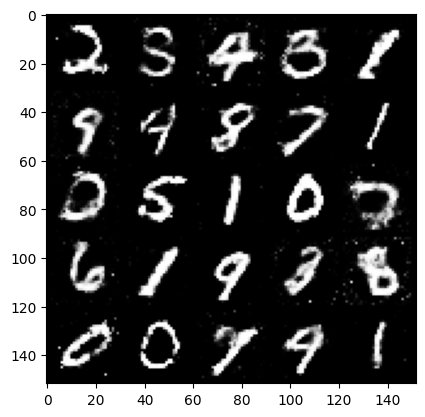

| Epoch: 055 | D_error: 1.153 | G_error: 1.053 | Time: 0m 32s


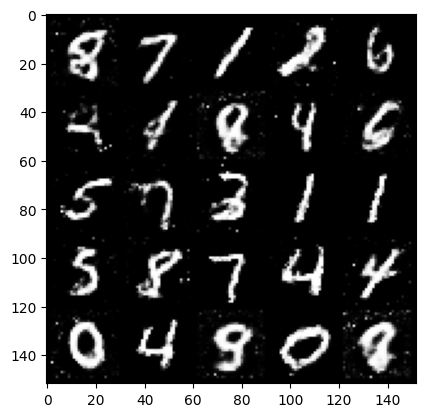

| Epoch: 060 | D_error: 1.097 | G_error: 1.182 | Time: 0m 33s


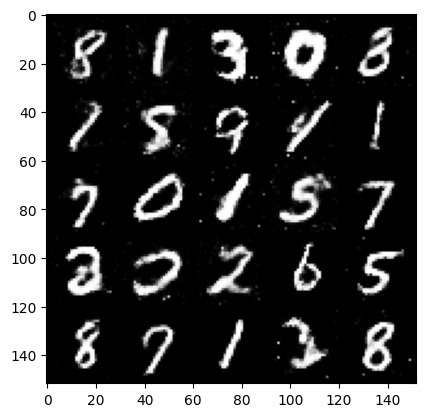

| Epoch: 065 | D_error: 1.048 | G_error: 1.249 | Time: 0m 32s


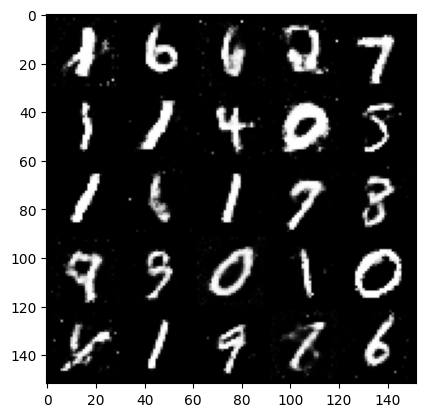

| Epoch: 070 | D_error: 1.273 | G_error: 1.154 | Time: 0m 33s


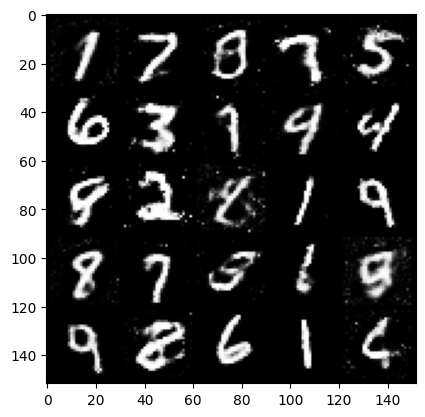

| Epoch: 075 | D_error: 1.054 | G_error: 1.033 | Time: 0m 33s


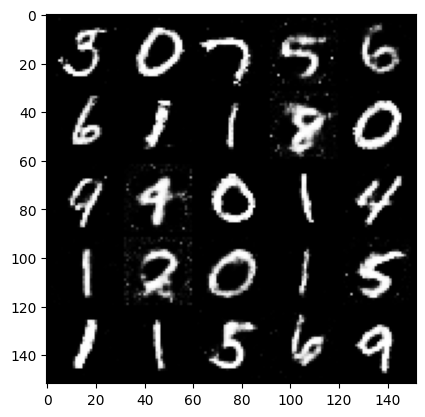

| Epoch: 080 | D_error: 1.243 | G_error: 1.223 | Time: 0m 33s


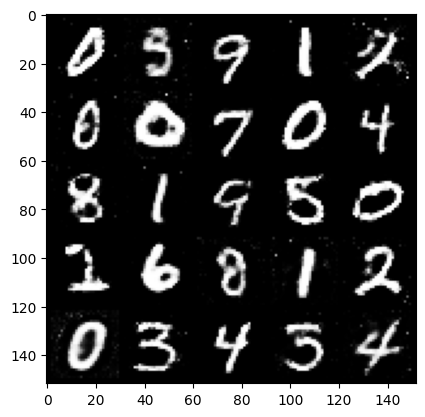

| Epoch: 085 | D_error: 1.270 | G_error: 0.957 | Time: 0m 33s


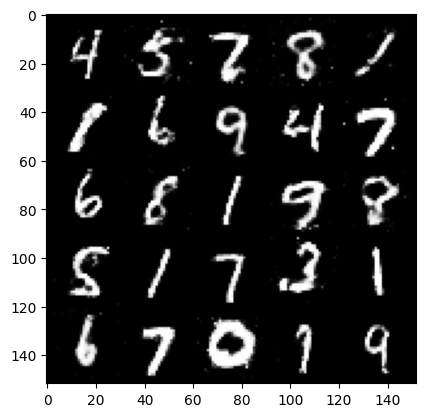

| Epoch: 090 | D_error: 1.149 | G_error: 0.866 | Time: 0m 32s


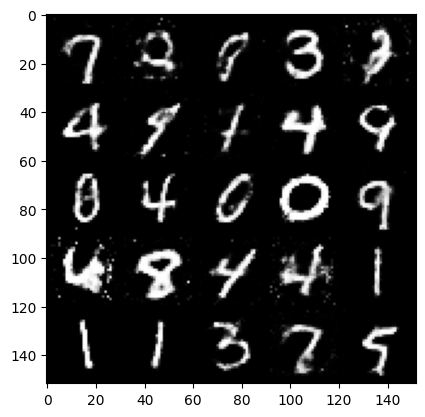

| Epoch: 095 | D_error: 1.096 | G_error: 0.944 | Time: 0m 33s


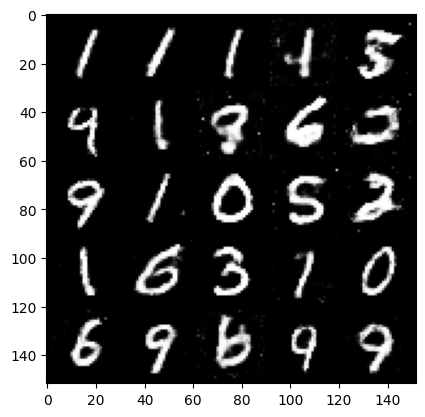

| Epoch: 100 | D_error: 0.973 | G_error: 0.986 | Time: 0m 34s


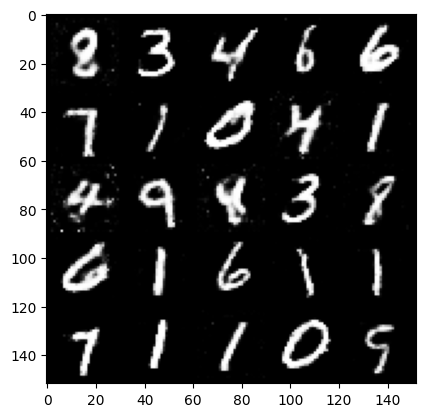

In [21]:
for epoch in range(1, N_EPOCHS+1):

    start_time = time.time()

    for _ in range(len(iterator)):

        """ TRAIN DISCRIMINATOR """

        #zero discriminator gradients
        discriminator.zero_grad()

        #get batch of real images
        x, _ = next(iter(iterator))

        #place images on GPU
        x = x.to(device)

        #flatten images
        x = x.view(-1, IMAGE_SIZE)

        #sample noise
        z = torch.randn(x.shape[0], LATENT_DIM).to(device)

        #generate images
        with torch.no_grad():
            generated_images = generator(z)

        #put real images through discriminator
        pred_real = discriminator(x)

        #how well does the discriminator detect real images?
        D_error_real = criterian(pred_real, real_labels)

        #put fake images through the discriminator
        #need to detach so don't backpropagate through generator
        pred_fake = discriminator(generated_images.detach())

        #how well does the discriminator detect fake images?
        D_error_fake = criterian(pred_fake, fake_labels)

        #get discriminator error
        D_error = D_error_real + D_error_fake

        #backpropagate errors to get gradients
        D_error.backward()

        #use gradient to update discriminator parameters
        D_optimizer.step()


        """ TRAIN GENERATOR """


        #zero generator gradients
        generator.zero_grad()

        #get batch of real images
        x, _ = next(iter(iterator))

        #place images on GPU
        x = x.to(device)

        #flatten images
        x = x.view(-1, IMAGE_SIZE)

        #sample noise
        z = torch.randn(x.shape[0], LATENT_DIM).to(device)

        #generate images
        generated_images = generator(z)

        #put fake images through the discriminator
        pred_fake = discriminator(generated_images)

        #how well does the generator fool the discriminator?
        G_error = criterian(pred_fake, real_labels)

        #backpropagate errors to get gradients
        G_error.backward()

        #use gradient to update generator parameters
        G_optimizer.step()

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if (epoch % PRINT_EVERY) == 0:

        #sample noise
        z = torch.randn(N_SHOW*N_SHOW, LATENT_DIM).to(device)

        #generate images
        with torch.no_grad():
            generated_images = generator(z)

        #reshape to (batch, channel, height, width)
        generated_images = generated_images.view(-1, 1, 28, 28)

        print(f'| Epoch: {epoch:03} | D_error: {D_error.item():.03f} | G_error: {G_error.item():.03f} | Time: {epoch_mins}m {epoch_secs}s')

        #save N_SHOW*N_SHOW images
        torchvision.utils.save_image(generated_images,
                                     f'images/gans/epoch{epoch:03}.png',
                                     nrow=N_SHOW,
                                     normalize=True)

        #display images
        img = plt.imread(f'images/gans/epoch{epoch:03}.png')
        plt.imshow(img)
        plt.show()